In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('alex_paper.mplstyle')
from TemporalNetwork import StaticTempNetwork
from scipy.sparse import csr_matrix
import compute_S_rate
import auxiliary_functions
import networkx as nx
from scipy import sparse

Could not load cython functions. Some functionality might be broken.
Could not load sparse_dot_mkl. Will use scipy.sparse for matrix products.


In [2]:
#Closed Formula Heat Diffussion
H_Heat = lambda t, n: np.log(n) - (n-1)/n*np.exp(-(n*t))*np.log((1+(n-1)*np.exp(-(n*t))) / (1-np.exp(-(n*t)))) - (n-1)/n * np.log(1-np.exp(-(n*t))) - 1/n*np.log(1+ (n-1)*np.exp((-n*t)))

In [3]:
def heat_kernel_path_graph(N: int, t: float) -> np.ndarray:
    """
    Return the heat‑diffusion transition matrix e^{−tL} for the simple path
    graph P_N (vertices 0,…,N−1 with edges i–(i+1)).

    Parameters
    ----------
    N : int
        Number of vertices of the path graph.
    t : float
        Diffusion time (non‑negative).

    Returns
    -------
    T : ndarray, shape (N, N)
        Row‑stochastic transition matrix whose (i, j) entry gives
        the probability of being at vertex j at time t when starting
        from vertex i.
    """
    # Eigenvalues λ_k = 2(1 − cos(π k / N)),  k = 0,…,N−1
    k = np.arange(N)
    lambdas = 2.0 * (1.0 - np.cos(np.pi * k / N))

    # Eigenvectors:
    #   – k = 0: constant vector (normalised)
    #   – k ≥ 1: DST‑II cosine modes with a half‑shift (j + 0.5)
    j = np.arange(N).reshape(-1, 1)          # column of vertex indices
    U0 = np.ones((N, 1)) / np.sqrt(N)        # constant eigenvector
    k1 = np.arange(1, N).reshape(1, -1)      # row of mode indices
    U_rest = np.sqrt(2.0 / N) * np.cos(np.pi * k1 * (j + 0.5) / N)

    U = np.hstack((U0, U_rest))              # full eigenvector matrix (orthonormal)

    # Heat kernel: U · diag(e^{−λ_k t}) · Uᵀ
    T = (U * np.exp(-lambdas * t)) @ U.T

    # Numerical clean‑up: set tiny negative round‑off to zero and renormalise rows
    T = np.clip(T, 0.0, None)
    T /= T.sum(axis=1, keepdims=True)

    return sparse.csr_matrix(T)

### Mean Field Approximation

In [4]:
# Entropy of each row of the mean-field transition matrix for ER graph
H_heat_meanfield = lambda t, n, p: -(
    (np.exp(-p * n * t) + (1 - np.exp(-p * n * t)) / n)
    * np.log(np.exp(-p * n * t) + (1 - np.exp(-p * n * t)) / n)
    + (n - 1)
    * ((1 - np.exp(-p * n * t)) / n)
    * np.log((1 - np.exp(-p * n * t)) / n)
)

## Plot Together

/Users/samuelkoovely/miniconda3/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:412: SparseEfficiencyWarning: splu converted its input to CSC format
  warn('splu converted its input to CSC format', SparseEfficiencyWarning)
/Users/samuelkoovely/miniconda3/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:302: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '


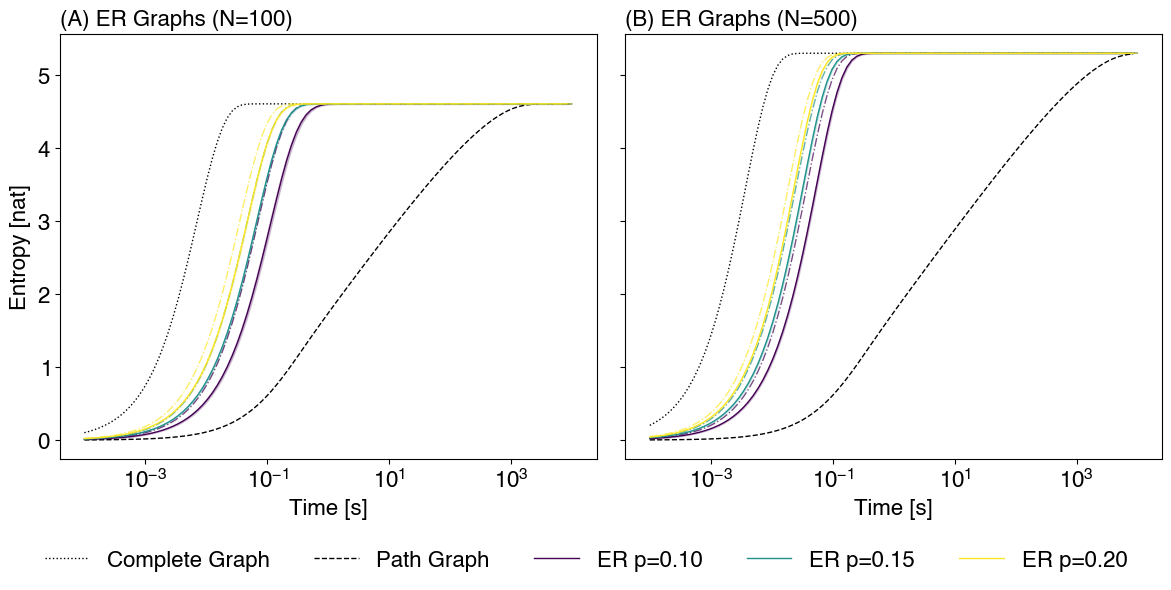

In [ ]:
# Global settings
Number_of_graphs = 5
lambda_value = 1.0
time = np.logspace(-4, 4, 100)

# Define parameters for 3 scenarios
scenarios = [
    {"N": 100, "p_values": [0.1, 0.15, 0.2], "title": "(A) ER Graphs (N=100)"},
    {"N": 200, "p_values": [0.1, 0.15, 0.2], "title": "(B) ER Graphs (N=500)"}
]

# Plot layout
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
base_color = 'k'

# Initialize for legend
legend_handles = []
legend_labels = []

for plot_idx, config in enumerate(scenarios):
    N = config["N"]
    p_values = config["p_values"]
    ax = axs[plot_idx]
    p0 = 1 / N * np.ones(N)

    # Color setup
    if plot_idx == 0:
        colours = [base_color]
        colours += auxiliary_functions.generate_viridis_colors(len(p_values))

    # Complete graph entropy
    entropy_complete = [H_Heat(t, N) for t in time]
    line_complete, = ax.plot(time, entropy_complete, label=f"K_{config['N']}", color=colours[0], linestyle=':')
    
    # Path graph entropy
    Transitions = [heat_kernel_path_graph(N, t) for t in time]
    formula_entropy_2 = compute_S_rate.compute_conditional_entropy(
        list_T=Transitions,
        lamda=lambda_value,
        force_csr=True,
        time_domain=list(np.arange(0, len(time) - 1)),
        p0=p0)
    entropy_path = formula_entropy_2[list(formula_entropy_2.keys())[0]][1:]
    line_path, = ax.plot(time[:-1], entropy_path, label=f"P_{config['N']}", color=colours[0], linestyle='--')

    if plot_idx == 0:
        legend_handles.extend([line_complete, line_path])
        legend_labels.extend(["Complete Graph", "Path Graph"])

    # Loop over ER graphs
    for i, p in enumerate(p_values):
        entropy_matrix = []

        for n_graph in range(Number_of_graphs):
            er_adj = nx.adjacency_matrix(nx.erdos_renyi_graph(N, p, seed=314+n_graph))
            er_rw = StaticTempNetwork(times=time, adjacency=csr_matrix(er_adj))
            er_rw.compute_laplacian_matrices(random_walk=False)
            er_rw.compute_inter_transition_matrices(lamda=1, dense_expm=False, use_sparse_stoch=False)
            er_rw.compute_transition_matrices(lamda=1)

            entropy_dict = compute_S_rate.compute_conditional_entropy(
                net=er_rw,
                list_T=er_rw.T[1],
                lamda=1,
                force_csr=True,
                time_domain=list(np.arange(len(time) - 1)),
                p0=p0,
            )
            entropy_vals = entropy_dict[list(entropy_dict.keys())[0]][1:]
            entropy_matrix.append(entropy_vals)

        # Mean and std
        entropy_array = np.array(entropy_matrix)
        mean_entropy = np.mean(entropy_array, axis=0)
        std_entropy = np.std(entropy_array, axis=0)

        # Plot ER average entropy
        line_er, = ax.plot(time[:-1], mean_entropy, label=f"ER p={p:.2f}", color=colours[i + 1])
        ax.fill_between(time[:-1], mean_entropy - std_entropy, mean_entropy + std_entropy,
                        color=colours[i + 1], alpha=0.2)

        # Mean-field approximation
        mean_field = [H_heat_meanfield(t, N, p) for t in time]
        line_mf, = ax.plot(time, mean_field, color=colours[i + 1], linestyle='-.', alpha=0.7)

        if plot_idx == 0:
            legend_handles.extend([line_er])
            legend_labels.extend([f"ER p={p:.2f}"])

    ax.set_xscale('log')
    ax.set_xlabel("Time [s]")
    if plot_idx ==0:
        ax.set_ylabel("Entropy [nat]")
    ax.set_title(config["title"], loc='left')

# Global legend
fig.legend(legend_handles, legend_labels, loc='lower center', ncol= len(legend_labels), bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.07, 1, 1])  # Leave space for global legend
#plt.savefig('/Users/samuelkoovely/Desktop/fig_entropy/mean_field.pdf', format='pdf', bbox_inches='tight')
plt.show()